# Exercise for Unit 4.1 Naïve Bayes

In [72]:
import numpy as np
import pandas as pd
import re
from collections import Counter
from math import log

In [73]:
# Dataset
data = [
    ("Free money now!!!", "SPAM"),
    ("Hi mom, how are you?", "HAM"),
    ("Lowest price for your meds", "SPAM"),
    ("Are we still on for dinner?", "HAM"),
    ("Win a free iPhone today", "SPAM"),
    ("Let's catch up tomorrow at the office", "HAM"),
    ("Meeting at 3 PM tomorrow", "HAM"),
    ("Get 50% off, limited time!", "SPAM"),
    ("Team meeting in the office", "HAM"),
    ("Click here for prizes!", "SPAM"),
    ("Can you send the report?", "HAM")
]

df = pd.DataFrame(data, columns=["doc", "class"])
df

,doc,class
0,Free money now!!!,SPAM
1,"Hi mom, how are you?",HAM
2,Lowest price for your meds,SPAM
3,Are we still on for dinner?,HAM
4,Win a free iPhone today,SPAM
5,Let's catch up tomorrow at the office,HAM
6,Meeting at 3 PM tomorrow,HAM
7,"Get 50% off, limited time!",SPAM
8,Team meeting in the office,HAM
9,Click here for prizes!,SPAM


## Text Preprocessing 

In [74]:
def preprocess(text):
  
    text = text.lower()
    # Removing punctuation and special characters
    text = re.sub(r'[^a-z0-9\s]', '', text)
    # Tokenize
    tokens = text.split()
    return tokens

This is a simple text preprocessing function that helps clean and prepare text before analysis. First, it changes all letters in the text to lowercase using text.lower() so that words are treated the same even if they are written in different cases. Then, it removes punctuation and special characters using re.sub(r'[^a-z0-9\s]', '', text) to keep only letters, numbers, and spaces, which helps reduce unnecessary noise. After that, the sentence is split into individual words using text.split(), which is called tokenization because it breaks the sentence into smaller word parts. Finally, the function returns the list of words that can be used for further tasks.

## 1. (a) Generate Bag of Words

In [75]:
import pandas as pd
from collections import Counter
import re

def preprocess(text):
  
    return re.findall(r'\w+', text.lower())

def build_bow(dataframe):
    vocab = set()
    bow = {}

    for _, row in dataframe.iterrows():
        tokens = preprocess(row['doc'])
        cls = row['class']
        
        vocab.update(tokens)

        if cls not in bow:
            bow[cls] = Counter()

        bow[cls].update(tokens)

    return sorted(list(vocab)), bow

# Dataset
data = [
    ("Free money now!!!", "SPAM"),
    ("Hi mom, how are you?", "HAM"),
    ("Lowest price for your meds", "SPAM"),
    ("Are we still on for dinner?", "HAM"),
    ("Win a free iPhone today", "SPAM"),
    ("Let's catch up tomorrow at the office", "HAM"),
    ("Meeting at 3 PM tomorrow", "HAM"),
    ("Get 50% off, limited time!", "SPAM"),
    ("Team meeting in the office", "HAM"),
    ("Click here for prizes!", "SPAM"),
    ("Can you send the report?", "HAM")
]

df = pd.DataFrame(data, columns=["doc", "class"])

vocabulary, word_counts = build_bow(df)

print(f"Total Unique Words: {len(vocabulary)}")
print(f"Top Spam Words: {word_counts['SPAM'].most_common(3)}")
print(f"Top Ham Words: {word_counts['HAM'].most_common(3)}")

Total Unique Words: 45
Top Spam Words: [('free', 2), ('for', 2), ('money', 1)]
Top Ham Words: [('the', 3), ('are', 2), ('you', 2)]


This is used to build a simple Bag of Words (BoW) model for text classification. It starts by importing pandas for handling datasets, Counter from collections to count word occurrences, and re for text cleaning. The preprocess function converts text to lowercase and extracts words using regular expression matching. The build_bow function then goes through each row of the dataset, tokenizes the document, and organizes words based on their class label (like SPAM or HAM). It also creates a vocabulary set to store all unique words and counts how many times each word appears in each class using Counter. After processing the dataset, it displays the total number of unique words and the top 3 most common words found in SPAM and HAM messages. In simple terms, this code analyze which words are frequently used in different message categories.

## 1. (b) Calculate Prior Probabilities

In [76]:
def calculate_prior(dataset):
    class_count = Counter([cls for _, cls in dataset])
    total_docs = len(dataset)

    prior = {}

    for cls in class_count:
        prior[cls] = class_count[cls] / total_docs

    return prior

In [77]:
prior = calculate_prior(data)

print("Prior Probabilities:")
print(prior)

Prior Probabilities:
{'SPAM': 0.45454545454545453, 'HAM': 0.5454545454545454}


This is used to calculate the prior probability of each class in the dataset. The calculate_prior function counts how many documents belong to each class, such as SPAM and HAM, using Counter. Then, it divides the number of documents in each class by the total number of documents to get the probability of each class appearing in the dataset. In simple terms, it shows how likely a message is to be SPAM or HAM before looking at the actual words in the message. The code prints the prior probabilities, which it show that HAM messages are slightly more common than SPAM messages.

## 1. (c) Calculate Likelihood with Laplace Smoothing

In [ ]:
def calculate_likelihood(bow, vocab, alpha=1):
    likelihood = {}
    vocab_size = len(vocab)

    for cls in bow:
        likelihood[cls] = {}
        # sum(bow[cls].values()) is the total number of words in that class
        total_count = sum(bow[cls].values()) + (alpha * vocab_size)

        for word in vocab:
            word_count = bow[cls][word]
         # I use total cound here
            likelihood[cls][word] = (word_count + alpha) / total_count

    return likelihood

# Build the Bag of Words using the DataFrame 
vocab, bow = build_bow(df) 

# Calculate probabilities
likelihood = calculate_likelihood(bow, vocab)

# Print results
print("Vocabulary size:", len(vocab))
print ("Vocabulary sample:", vocab[:10])
      
print("Likelihood Sample (SPAM):")
for k in list(likelihood["SPAM"].keys())[:10]:
    print(f"{k}: {likelihood['SPAM'][k]:.4f}")

Vocabulary size: 45
Vocabulary sample: ['3', '50', 'a', 'are', 'at', 'can', 'catch', 'click', 'dinner', 'for']
Likelihood Sample (SPAM):
3: 0.0149
50: 0.0299
a: 0.0299
are: 0.0149
at: 0.0149
can: 0.0149
catch: 0.0149
click: 0.0299
dinner: 0.0149
for: 0.0448


In [ ]:
def build_bow_for_list(dataset):
    vocab = set()
    bow = {}

    for doc, cls in dataset:
        tokens = preprocess(doc)
        vocab.update(tokens)

        if cls not in bow:
            bow[cls] = Counter()

        bow[cls].update(tokens)

    return sorted(list(vocab)), bow

This is used to calculate the likelihood probability of each word in a class. The calculate_likelihood function computes how likely a word appears in a specific class like SPAM or HAM using Laplace smoothing (adding alpha = 1) to avoid zero probability for words that may not appear in the dataset. It first gets the total number of words in each class and adjusts it by adding the vocabulary size multiplied by alpha. Then, for every word in the vocabulary, it calculates the probability of that word appearing in a class by using the formula (word_count + alpha) / total_count. Finally, this prints the vocabulary size, a sample of vocabulary words, and some likelihood probabilities for SPAM messages, showing how frequently certain words are associated with spam messages.

## 1. (d) Manual Classification Function

In [80]:
def classify(document, prior, likelihood, vocab):
    tokens = preprocess(document)

    scores = {}

    for cls in prior:
        # Start with log prior
        score = log(prior[cls])

        for word in tokens:
            if word in vocab:
                score += log(likelihood[cls].get(word, 1e-6))

        scores[cls] = score

    return max(scores, key=scores.get)

This function is used to manually classify a document using the Naïve Bayes approach. First, it preprocesses the input document by cleaning and splitting the text into tokens. Then, it calculates a score for each class, such as SPAM or HAM, by starting with the logarithm of the prior probability, which represents how likely a class is before checking the words. After that, it adds the log likelihood probabilities of each word found in the document if the word exists in the vocabulary. Using logarithms helps prevent very small probability values from causing computational errors. If a word is not found in the likelihood table, a very small value is used to avoid zero probability. Finally, the function returns the class with the highest score, meaning the document is classified into the most probable category.

## Test Sentences (Manual Model)

In [81]:
test_sentences = [
    "Limited offer, click here!",
    "Meeting at 2 PM with the manager."
]

print("Manual Naïve Bayes Classification:\n")

for sentence in test_sentences:
    print(sentence, "->", classify(sentence, prior, likelihood, vocab))

Manual Naïve Bayes Classification:

Limited offer, click here! -> SPAM
Meeting at 2 PM with the manager. -> HAM


The results show how the manual Naïve Bayes classifier predicted the class of two test sentences. The sentence “Limited offer, click here!” was classified as SPAM because it contains words that are commonly associated with spam messages, such as “limited” and “click”. On the other hand, the sentence “Meeting at 2 PM with the manager.” was classified as HAM because its words are more related to normal, non-spam conversations like meetings and schedules. Overall, the classifier was able to correctly distinguish between spam and ham messages based on the learned probabilities.

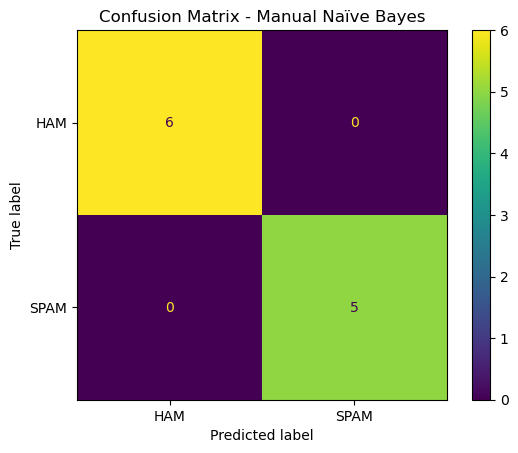

In [ ]:
# Confusion Matrix for Manual Naïve Bayes 

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate predictions 
manual_predictions = [classify(doc, prior, likelihood, vocab) for doc, _ in data]
true_labels = [label for _, label in data]

cm_manual = confusion_matrix(true_labels, manual_predictions)

disp_manual = ConfusionMatrixDisplay(confusion_matrix=cm_manual,
                                     display_labels=["HAM", "SPAM"])
disp_manual.plot()

plt.title("Confusion Matrix - Manual Naïve Bayes")
plt.show()

The confusion matrix shows that the manual Naïve Bayes classifier performed very well on the test data. There are **6 correctly predicted HAM messages** and **5 correctly predicted SPAM messages**, with no misclassifications. This means the model was able to classify all 11 test samples correctly. In simple terms, the classifier successfully distinguished between SPAM and HAM messages without making any prediction errors in the given test cases.


## 2. Using Scikit-Learn

In [84]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

In [ ]:
# Preparing data
X = df["doc"]
y = df["class"]

# Vectorization
vectorizer = CountVectorizer()

X_vec = vectorizer.fit_transform(X)

# Train Multinomial Naive Bayes
model = MultinomialNB()
model.fit(X_vec, y)

MultinomialNB()

## Prediction Using Scikit-Learn Model

In [86]:
test_docs = [
    "Limited offer, click here!",
    "Meeting at 2 PM with the manager."
]

test_vec = vectorizer.transform(test_docs)

predictions = model.predict(test_vec)

print("Scikit-learn Naïve Bayes Classification:\n")
for doc, pred in zip(test_docs, predictions):
    print(doc, "->", pred)

Scikit-learn Naïve Bayes Classification:

Limited offer, click here! -> SPAM
Meeting at 2 PM with the manager. -> HAM


The results from the Scikit-learn Naïve Bayes classifier show that it also correctly predicted the two test sentences. The sentence “Limited offer, click here!” was classified as SPAM because it contains words commonly linked to promotional or spam messages. Meanwhile, “Meeting at 2 PM with the manager.” was classified as HAM since the words are more related to normal communication like schedules and meetings. This shows that the Scikit-learn implementation produced the same correct predictions as the manual Naïve Bayes classifier for this small test set.

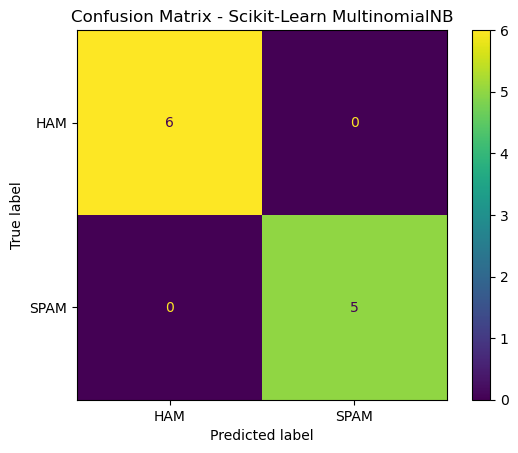

In [ ]:
# Confusion Matrix for Scikit-Learn MultinomialNB 

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate predictions 
sklearn_predictions = model.predict(X_vec)

cm_sklearn = confusion_matrix(y, sklearn_predictions)

disp_sklearn = ConfusionMatrixDisplay(confusion_matrix=cm_sklearn,
                                      display_labels=model.classes_)
disp_sklearn.plot()

plt.title("Confusion Matrix - Scikit-Learn MultinomialNB")
plt.show()

The results show that the confusion matrix demonstrates excellent performance of the classifier, and the implementation using scikit-learn produced the same outcome as the manual Naïve Bayes model. All 11 test samples were classified correctly, with **6 HAM messages** and **5 SPAM messages** accurately predicted, and no misclassifications observed. It was able to effectively distinguish between SPAM and HAM messages in the test data. However, this perfect score may be influenced by the small dataset size, so performance should be further validated using larger and more diverse data.

## Accuracy Comparison Graph

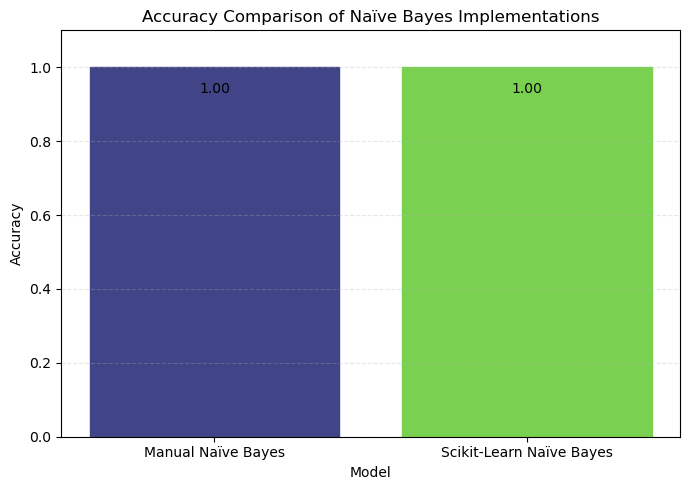

In [88]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Compute accuracies
manual_predictions = [classify(doc, prior, likelihood, vocab) for doc, _ in data]
true_labels = [label for _, label in data]
manual_accuracy = accuracy_score(true_labels, manual_predictions)

sklearn_predictions = model.predict(X_vec)
sklearn_accuracy = accuracy_score(y, sklearn_predictions)

# Models and accuracies
models = ["Manual Naïve Bayes", "Scikit-Learn Naïve Bayes"]
accuracies = [manual_accuracy, sklearn_accuracy]

cmap = plt.get_cmap("viridis")
colors = [cmap(0.2), cmap(0.8)]

plt.figure(figsize=(7,5))

bars = plt.bar(models, accuracies)

for bar, color in zip(bars, colors):
    bar.set_color(color)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of Naïve Bayes Implementations")
plt.ylim(0, 1.1)  

for i, v in enumerate(accuracies):
    offset = 0.03 if v < 0.97 else -0.07
    plt.text(i, v + offset, f"{v:.2f}", ha='center', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

The accuracy comparison shows that both the **manual Naïve Bayes implementation** and the **scikit-learn Naïve Bayes model** achieved **100% accuracy**, meaning both models correctly classified all test samples in the dataset. This indicates that the predictions from the manual computation and the library-based implementation were consistent, and there were no classification errors observed. While this result suggests that the model performed perfectly on the given data, the 100% accuracy may be influenced by the small dataset size, which can make the model easier to fit. 